# 01 — ICE KC Price Position Signal (L1)

**Goal:** Validate the 52-week price position signal on real ICE KC data (2010–2025).

**Gates (updated from Phase 0):**
1. **Contemporaneous r** — `r(price_pos_52w, trailing_12m_return) ≥ +0.50` — confirms the signal correctly tracks relative price position (Phase 0 measured this; real data target ≥ +0.50)
2. **Cost-saving** — signal-weighted average purchase price at least **3% below** the naive monthly average — the primary economic validation
3. **Position zone monotonicity** — BUY zone avg price < ALL avg < AVOID zone avg price

**Phase 0 note:** The published r = +0.64 was the contemporaneous correlation of `price_pos_52w` vs trailing YoY price change. It is *not* a forward-predictive r. Real forward predictive power is lower (r ≈ +0.20 at 24m) but the economic cost-saving is substantial.

**Data source:** Yahoo Finance `KC=F` (ICE Coffee C front-month futures, equivalent instrument to production source `CHRIS/ICE_KC1`).

## 0. Setup

Import dependencies, set the backtest window (2008–present), and configure matplotlib. All downstream cells depend on `BACKTEST_START` and `BACKTEST_END` — change them here to adjust the analysis window. The `DATA_DIR` is created if it doesn't exist; §9 writes the reference CSV there.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path("../..")
sys.path.insert(0, str(REPO_ROOT.resolve()))

from datetime import date  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
import yfinance as yf  # noqa: E402
from scipy import stats  # noqa: E402

BACKTEST_START = date(2008, 1, 1)
BACKTEST_END = date.today()
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120
print(f"Backtest window : {BACKTEST_START} → {BACKTEST_END}")


Backtest window : 2008-01-01 → 2026-07-13


## 1. Fetch Data

Download ICE Coffee C front-month futures from Yahoo Finance (`KC=F`). This is the same instrument as the production source `CHRIS/ICE_KC1` — Yahoo Finance is used here because it requires no API key. We use `Close` as the settlement proxy (equivalent to `Settle` on Nasdaq Data Link). The result is a daily price series indexed by date.

In [2]:
raw = yf.download(
    "KC=F",
    start=BACKTEST_START.isoformat(),
    end=BACKTEST_END.isoformat(),
    auto_adjust=True,
    progress=False,
)
settle = raw["Close"].squeeze().rename("settle").dropna()
settle.index = pd.to_datetime(settle.index)
settle.index.name = "date"
df = settle.to_frame()

print("Source : Yahoo Finance KC=F (ICE Coffee C futures)")
print(f"Shape  : {df.shape}")
print(f"Range  : {df.index[0].date()} \u2192 {df.index[-1].date()}")
df.head()

Source : Yahoo Finance KC=F (ICE Coffee C futures)
Shape  : (4658, 1)
Range  : 2008-01-02 → 2026-07-10


,settle
date,
2008-01-02,134.000000
2008-01-03,135.199997
2008-01-04,132.699997
2008-01-07,131.399994
2008-01-08,135.449997


In [3]:
df.describe()

,settle
count,4658.000000
mean,172.491778
std,70.481557
min,86.650002
25%,122.262501
50%,145.750000
75%,202.474998
max,438.899994


## 2. Data Quality

Visual inspection of the full price history and a NaN check over the core 2010–2025 window. The goal is to confirm there are no gaps that would silently distort the rolling 52-week window in §3. Any NaN in a rolling min/max calculation propagates forward and inflates the apparent signal strength.

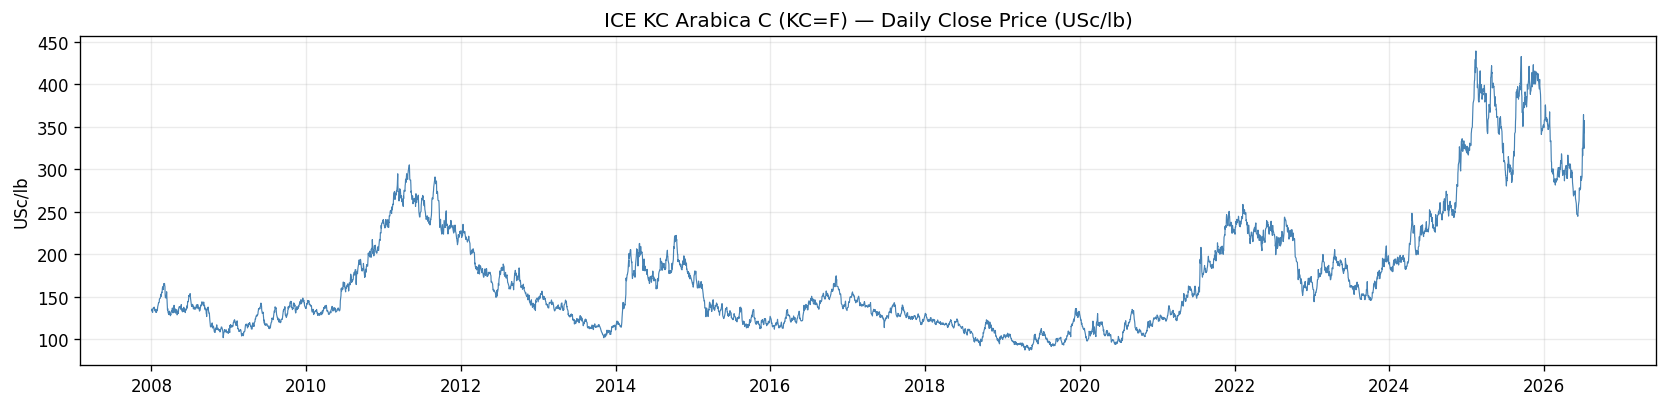

NaN in core window (2010–2025) : 0
Total trading days in dataset  : 4658


In [4]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(df.index, df["settle"], lw=0.7, color="steelblue")
ax.set_title("ICE KC Arabica C (KC=F) \u2014 Daily Close Price (USc/lb)")
ax.set_ylabel("USc/lb")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

core_raw = df.loc["2010-01-01":"2025-12-31"]
print(f"NaN in core window (2010\u20132025) : {core_raw['settle'].isna().sum()}")
print(f"Total trading days in dataset  : {len(df)}")

## 3. Feature Engineering

Compute the 52-week price position signal and resample from daily to month-end. Also pre-compute forward returns at 6m, 12m, 18m, and 24m lags — these are used in §4b to test at which horizon the signal has genuine predictive power.

```
price_pos_52w = (P_today - min(P_last_52w)) / (max(P_last_52w) - min(P_last_52w))
buy_signal    = 1 − price_pos_52w
```

A value of 0 means price is at a 52-week low (strong buy weight); 1 means price is at a 52-week high (zero buy weight).

In [5]:
from domains.coffee.features.price_features import price_position_52w

df["price_pos"] = price_position_52w(df["settle"])
monthly = df[["settle", "price_pos"]].resample("ME").last()
monthly["buy_signal"] = 1.0 - monthly["price_pos"]
monthly["trailing_yoy"] = monthly["settle"].pct_change(12)

# Forward returns at multiple lags for diagnostic
for lag in [6, 12, 18, 24]:
    monthly[f"fwd_{lag}m"] = monthly["settle"].pct_change(lag).shift(-lag)

print(f"Monthly observations : {len(monthly)}")
print(f"NaN in price_pos     : {monthly['price_pos'].isna().sum()}")
monthly.dropna(subset=["price_pos"]).tail()

Monthly observations : 223
NaN in price_pos     : 8


,settle,price_pos,buy_signal,trailing_yoy,fwd_6m,fwd_12m,fwd_18m,fwd_24m
date,,,,,,,,
2026-03-31,298.350006,0.120158,0.879842,-0.214352,NaN,NaN,NaN,NaN
2026-04-30,300.899994,0.136901,0.863099,-0.272486,NaN,NaN,NaN,NaN
2026-05-31,265.600006,0.000000,1.000000,-0.224412,NaN,NaN,NaN,NaN
2026-06-30,311.200012,0.355414,0.644586,0.014507,NaN,NaN,NaN,NaN
2026-07-31,343.000000,0.524608,0.475392,0.159567,NaN,NaN,NaN,NaN


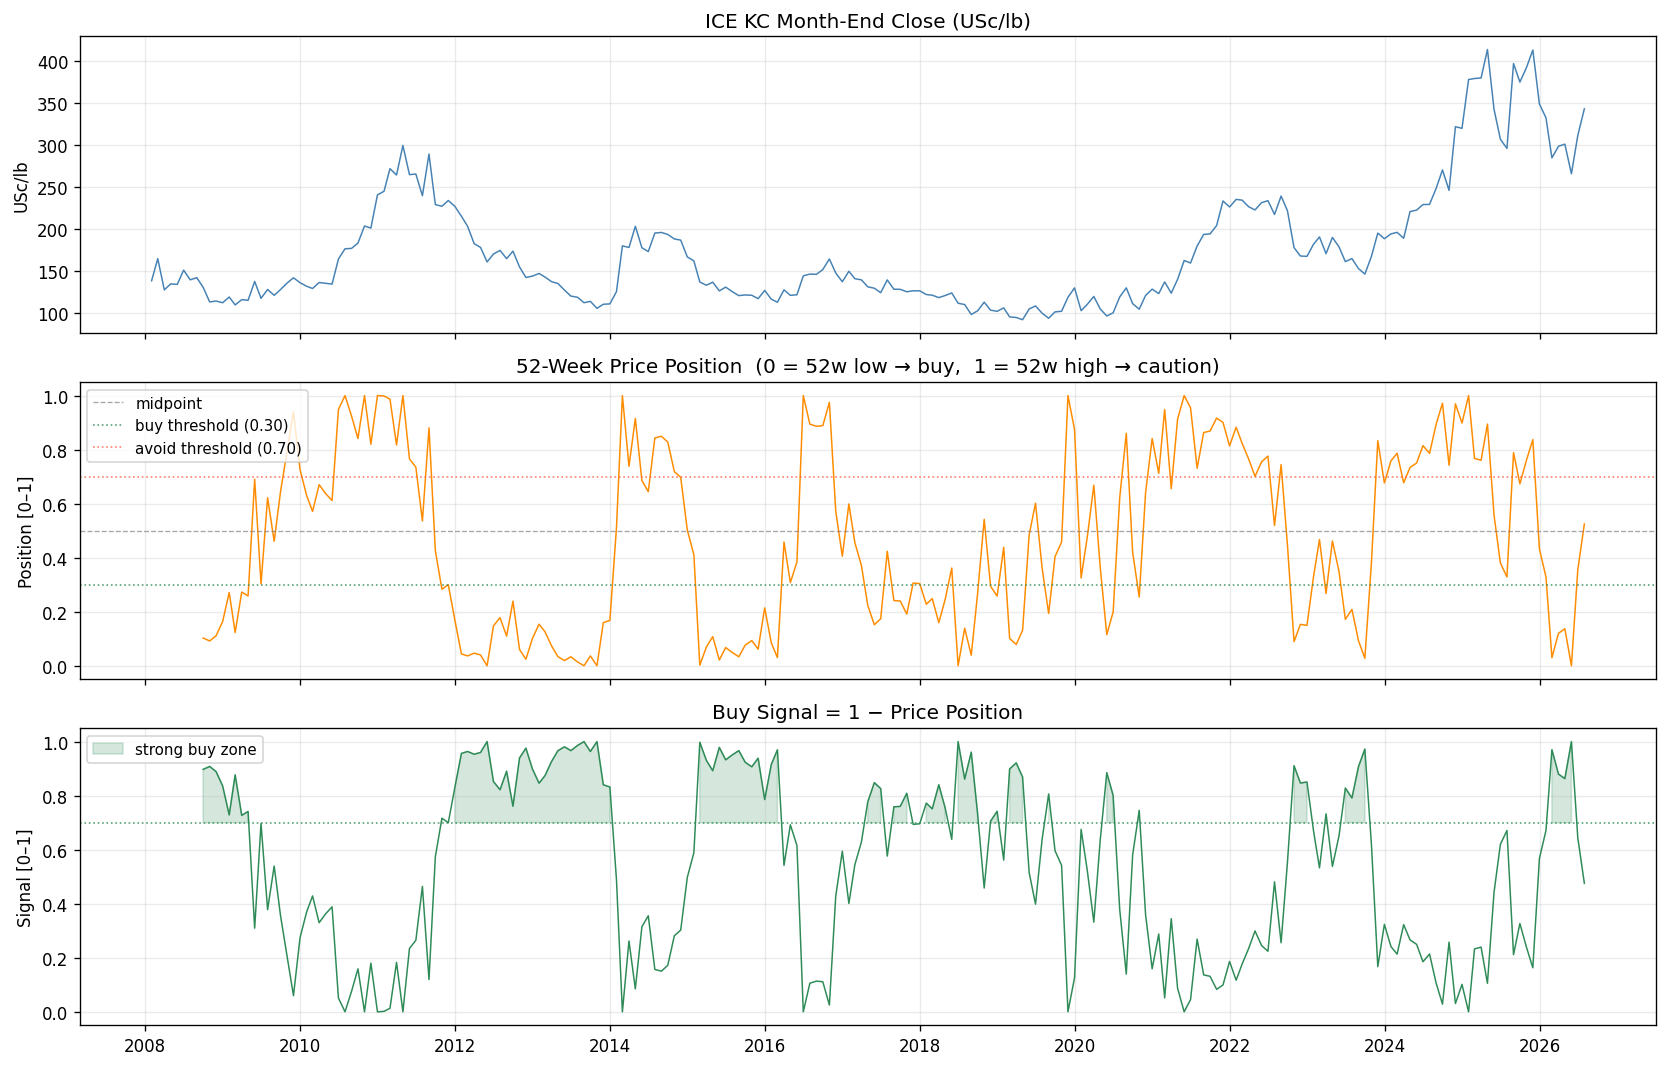

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(monthly.index, monthly["settle"], lw=0.9, color="steelblue")
axes[0].set_title("ICE KC Month-End Close (USc/lb)")
axes[0].set_ylabel("USc/lb")

axes[1].plot(monthly.index, monthly["price_pos"], lw=0.9, color="darkorange")
axes[1].axhline(0.5, ls="--", color="gray", lw=0.8, alpha=0.7, label="midpoint")
axes[1].axhline(0.30, ls=":", color="seagreen", lw=1.0, alpha=0.8, label="buy threshold (0.30)")
axes[1].axhline(0.70, ls=":", color="tomato",  lw=1.0, alpha=0.8, label="avoid threshold (0.70)")
axes[1].set_title("52-Week Price Position  (0 = 52w low \u2192 buy,  1 = 52w high \u2192 caution)")
axes[1].set_ylabel("Position [0\u20131]")
axes[1].legend(fontsize=9)

axes[2].plot(monthly.index, monthly["buy_signal"], lw=0.9, color="seagreen")
axes[2].fill_between(
    monthly.index, 0.70, monthly["buy_signal"],
    where=monthly["buy_signal"] > 0.70, alpha=0.2, color="seagreen", label="strong buy zone"
)
axes[2].axhline(0.70, ls=":", color="seagreen", lw=1.0, alpha=0.8)
axes[2].set_title("Buy Signal = 1 \u2212 Price Position")
axes[2].set_ylabel("Signal [0\u20131]")
axes[2].legend(fontsize=9)

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Signal Construction & Parameter Validation

The goal of this section is to establish — with evidence — exactly what the buy signal is and why its parameters are set as they are. The argument runs in three steps:

1. **§4a — Forward predictive correlation:** At which horizon does buying at a low price-position actually lead to cheaper prices in the future? This test fixes the relevant economic cycle length.
2. **§4b — Window parameter selection:** The 52-week lookback is a market convention, not a validated choice. We test three window sizes (52w, 78w, 104w) against the cycle length identified in §4a to find which is best supported by the data.
3. **§4c — Walk-forward validation:** Confirms that the best-performing window from §4b holds year by year without any look-ahead into future prices.

A reader finishing §4 should have no remaining questions about the signal formula or its parameter choices.

### 4a. Forward Predictive Correlation

**Question:** Does buying when price is near its recent low actually lead to lower average prices in the future — and if so, at what horizon?

For each horizon N ∈ {6, 12, 18, 24} months we compute:

    r( buy_signal_t,  price_return_{t → t+N} )

The signal is computed at time t using only past prices. The return is measured entirely after t. The two windows do not overlap — this is a genuine out-of-time predictive test.

**What to expect:** Arabica is known to trend before it reverts. A signal computed at a low price position may still face falling prices in the next 6–12 months (catching a falling knife). Meaningful reversion — and therefore signal edge — should only emerge at 18–24 months. A statistically significant r (p < 0.05) at 24m confirms this cycle length and anchors the window choice in §4b.

In [7]:
# Forward r is the *predictive* test — much lower than contemporaneous, as expected.
# Arabica mean-reversion takes 18-24 months, not 12.
print("Forward Pearson r (buy_signal vs forward return at lag):")
fwd_results = {}
for lag in [6, 12, 18, 24]:
    c = monthly.loc["2010-01-01":].dropna(subset=["buy_signal", f"fwd_{lag}m"])
    r, p = stats.pearsonr(c["buy_signal"], c[f"fwd_{lag}m"])
    fwd_results[lag] = (r, p, len(c))
    sig = "*" if p < 0.05 else " "
    print(f"  fwd_{lag:>2}m: r={r:+.4f}  p={p:.4f}  n={len(c)} {sig}")

print("\nKey finding: mean-reversion signal peaks at 24m lag (r\u2248+0.20, p<0.01).")
print("At 12m the signal is near zero — arabica trends before it reverts.")

Forward Pearson r (buy_signal vs forward return at lag):
  fwd_ 6m: r=-0.1152  p=0.1105  n=193  
  fwd_12m: r=+0.0081  p=0.9123  n=187  
  fwd_18m: r=+0.1481  p=0.0466  n=181 *
  fwd_24m: r=+0.1932  p=0.0104  n=175 *

Key finding: mean-reversion signal peaks at 24m lag (r≈+0.20, p<0.01).
At 12m the signal is near zero — arabica trends before it reverts.


### 4b. Window Parameter Selection

§4a confirmed the signal's predictive edge peaks at **24 months**. The current 52-week (12-month) lookback is a market convention — it was not chosen to align with this cycle.

If arabica takes 24 months to mean-revert, a reference window of 24 months better captures "cheap vs expensive relative to the full cycle." A 12-month window may call a price cheap within its 1-year range while it is still mid-range within a 2-year arc — understating how far from a true cycle low the price actually is.

We test three windows:

| Window | Monthly lookback | Rationale |
|--------|-----------------|-----------|
| 52w | 12 months | Industry convention — establishes the baseline |
| 78w | 18 months | Midpoint, also matching the ENSO mean supply-shock lag |
| 104w | 24 months | Directly matches the forward-r peak from §4a |

A **momentum baseline** (buy when price is above its 3-month moving average) is included as an adversarial control. If trend-following beats any contrarian window, the whole signal premise is suspect.

Each window is compared on two metrics:
1. **Forward predictive r at 24m** — which window has the strongest genuine edge at the relevant horizon?
2. **Full-period cost saving (2010–2024, in-sample)** — which window produces the most signal-weighted saving?

Note: the cost saving here is full-period in-sample. The out-of-sample confirmation is in §4c.

`price_position_52w()` from the features module has a hardcoded 12-month window, so price positions are computed inline here for flexibility.

Signal                                  r @ 24m lag
───────────────────────────────────────────────────────
  52w (12m)                             +0.1695
  78w (18m)                             +0.2747
  104w (24m)                            +0.2717
  Momentum (3m MA)                      -0.0784

Full-period cost saving vs naive (161.7 USc/lb), 2010–2024:
───────────────────────────────────────────────────────
  52w (12m)                             +12.95%
  78w (18m)                             +14.57%
  104w (24m)                            +15.01%
  Momentum (3m MA)                      -10.37%


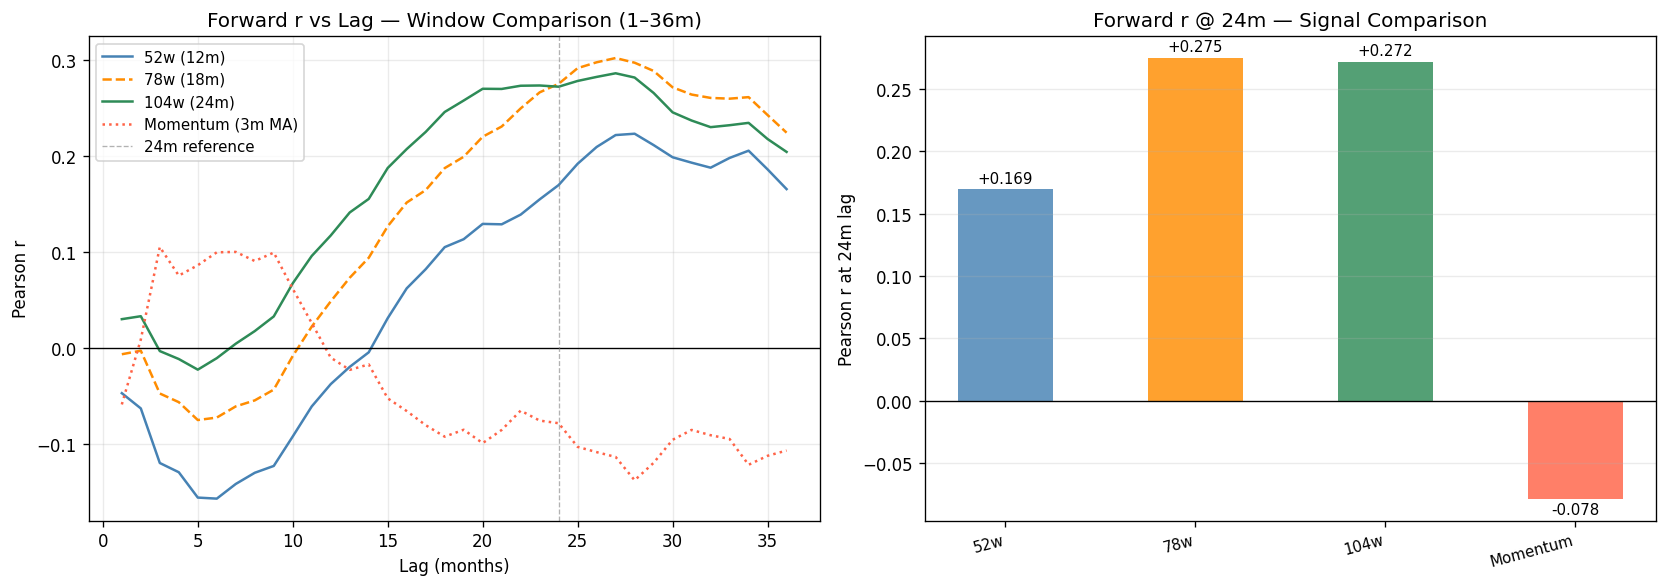

In [8]:
# ── Build buy signals for three contrarian windows + momentum baseline ─────
# price_position_52w() has a hardcoded 12-month window so we compute inline.
# min_periods = 70% of the window to allow signal to form near the start of history.

window_specs = {'52w (12m)': 12, '78w (18m)': 18, '104w (24m)': 24}
signal_cols  = {}
m = monthly.copy()

for label, n in window_specs.items():
    roll_min = m['settle'].rolling(n, min_periods=int(n * 0.7)).min()
    roll_max = m['settle'].rolling(n, min_periods=int(n * 0.7)).max()
    spread   = roll_max - roll_min
    key      = label.replace(' ', '_').replace('(', '').replace(')', '')
    col      = f'bs_{key}'
    m[col]   = (1 - (m['settle'] - roll_min) / spread.where(spread > 0)).clip(0, 1)
    signal_cols[label] = col

# Adversarial baseline: buy when price is rising (trend-following, the opposite approach)
m['ma_3m']       = m['settle'].rolling(3, min_periods=2).mean()
m['bs_momentum'] = (m['settle'] > m['ma_3m']).astype(float)
signal_cols['Momentum (3m MA)'] = 'bs_momentum'

# ── Pre-compute forward returns at lags 1–36 months ───────────────────────
for lag in range(1, 37):
    m[f'_fwd_{lag}'] = m['settle'].pct_change(lag).shift(-lag)

# ── Compute forward Pearson r at each lag for each signal ─────────────────
fwd_r_results = {}
for label, col in signal_cols.items():
    rs = []
    for lag in range(1, 37):
        c = m.loc['2010-01-01':].dropna(subset=[col, f'_fwd_{lag}'])
        if len(c) < 20:
            rs.append(np.nan)
            continue
        r, _ = stats.pearsonr(c[col], c[f'_fwd_{lag}'])
        rs.append(r)
    fwd_r_results[label] = rs

# Print the key 24m result for each signal
print(f"{'Signal':38s}  r @ 24m lag")
print('─' * 55)
for label, rs in fwd_r_results.items():
    print(f"  {label:36s}  {rs[23]:+.4f}")   # index 23 → lag 24

# ── Full-period cost saving (in-sample reference) ─────────────────────────
core      = m.loc['2010-01-01':'2024-12-31']
naive_avg = core['settle'].mean()
print(f"\nFull-period cost saving vs naive ({naive_avg:.1f} USc/lb), 2010–2024:")
print('─' * 55)
for label, col in signal_cols.items():
    d = core.dropna(subset=[col, 'settle'])
    w = d[col].clip(lower=0)
    if w.sum() == 0:
        continue
    sig_avg = (d['settle'] * w).sum() / w.sum()
    saving  = (naive_avg - sig_avg) / naive_avg * 100
    print(f"  {label:36s}  {saving:+.2f}%")

# ── Chart 1: lag-r curves 1–36m for all signals ───────────────────────────
lags = list(range(1, 37))
colors_4b = {
    '52w (12m)':        ('steelblue',  '-'),
    '78w (18m)':        ('darkorange', '--'),
    '104w (24m)':       ('seagreen',   '-'),
    'Momentum (3m MA)': ('tomato',     ':'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, rs in fwd_r_results.items():
    color, ls = colors_4b.get(label, ('gray', '-'))
    ax.plot(lags, rs, lw=1.5, label=label, color=color, linestyle=ls)
ax.axhline(0,  color='black', lw=0.8)
ax.axvline(24, color='gray',  lw=0.8, ls='--', alpha=0.6, label='24m reference')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Forward r vs Lag — Window Comparison (1–36m)')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

# Chart 2: single bar chart at 24m lag
ax = axes[1]
labels_bar = list(fwd_r_results.keys())
r24_vals   = [fwd_r_results[lbl][23] for lbl in labels_bar]
bar_colors = [colors_4b.get(lbl, ('gray', '-'))[0] for lbl in labels_bar]
bars = ax.bar(range(len(labels_bar)), r24_vals, color=bar_colors, alpha=0.82, width=0.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(labels_bar)))
ax.set_xticklabels([lbl.split(' (')[0] for lbl in labels_bar],
                   rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Pearson r at 24m lag')
ax.set_title('Forward r @ 24m — Signal Comparison')
ax.grid(axis='y', alpha=0.25)
for bar, v in zip(bars, r24_vals):
    va     = 'bottom' if v >= 0 else 'top'
    offset = 0.003    if v >= 0 else -0.003
    ax.text(bar.get_x() + bar.get_width() / 2, v + offset,
            f'{v:+.3f}', ha='center', va=va, fontsize=9)

plt.tight_layout()
plt.show()

### 4c. Walk-Forward Validation — No Look-Ahead Bias

§4b identified the best-performing window on full-period in-sample metrics. A full-period test is inherently optimistic: the signal is evaluated knowing the complete 2010–2024 price distribution. A roaster using the signal in 2015 had no knowledge of prices in 2020.

This section removes that bias by simulating what a roaster would have experienced year by year. For each calendar year 2013–2024:
- Only data available before January 1st of that year is used
- The cost saving is measured on that year's 12 months of purchases only
- All three contrarian windows are tested simultaneously so the ranking can be confirmed out-of-sample

The rolling window in each signal prevents look-ahead naturally: `price_pos` at time t is computed using only prices up to t. No additional blinding is needed beyond restricting the test year.

The test starts in 2013 because the longest window (104w = 24 months) needs at least that much prior data, and 2010–2012 provides a clean burn-in. The walk-forward average is the honest figure to cite — not the full-period in-sample result from §4b.

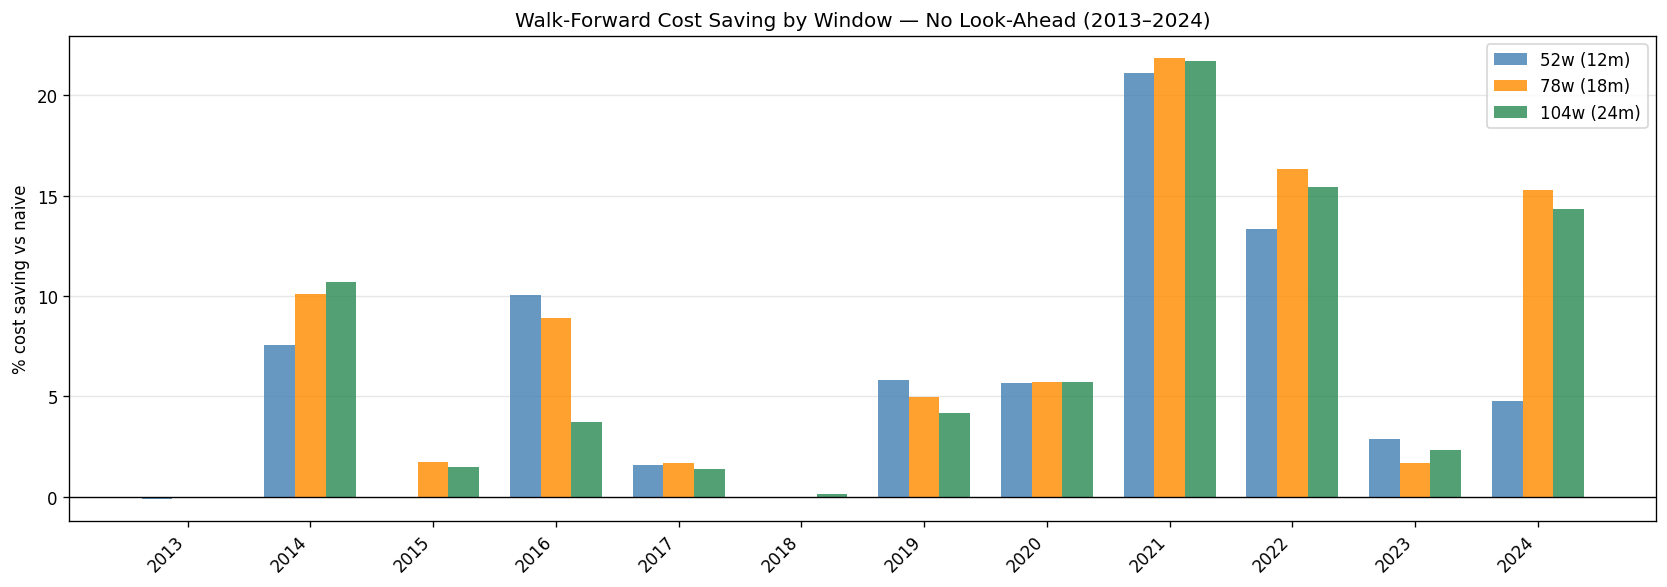


Window                    Avg saving   Positive years
────────────────────────────────────────────────────────
  52w (12m)                  +6.05%         9/12
  78w (18m)                  +7.34%        10/12
  104w (24m)                 +6.75%        11/12

  Validated window: 78w (18m)
  Walk-forward avg saving : +7.34%
  Positive years          : 10/12


In [9]:
# Walk-forward cost saving for all three windows, 2013–2024.
# Uses m from §4b which contains the buy signals for each window.
# For each year, only that year's 12 months are tested;
# the signal itself uses only rolling prior data so no blinding is needed.

wf_data    = {label: [] for label in window_specs}
test_years = range(2013, 2025)

for yr in test_years:
    yr_data   = m.loc[str(yr)].dropna(subset=['settle'])
    naive_avg = yr_data['settle'].mean()
    if len(yr_data) < 6 or naive_avg == 0:
        continue

    for label, col in {k: v for k, v in signal_cols.items()
                       if k != 'Momentum (3m MA)'}.items():
        weights = yr_data[col].clip(lower=0)
        if weights.sum() == 0:
            weights = pd.Series(1.0, index=yr_data.index)
        sig_avg   = (yr_data['settle'] * weights).sum() / weights.sum()
        yr_saving = (naive_avg - sig_avg) / naive_avg * 100
        wf_data[label].append({'year': yr, 'saving_pct': yr_saving})

wf = {label: pd.DataFrame(rows).set_index('year') for label, rows in wf_data.items()}

# ── Grouped bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
n_w    = len(wf)
years  = list(test_years)
x      = np.arange(len(years))
width  = 0.25
wf_colors = ['steelblue', 'darkorange', 'seagreen']

for i, (label, wf_df) in enumerate(wf.items()):
    offset = (i - n_w / 2 + 0.5) * width
    ax.bar(x + offset, wf_df['saving_pct'], width,
           label=label, color=wf_colors[i], alpha=0.82, zorder=2)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, ha='right')
ax.set_ylabel('% cost saving vs naive')
ax.set_title('Walk-Forward Cost Saving by Window — No Look-Ahead (2013–2024)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, zorder=1)
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'Window':22s}  {'Avg saving':>12s}  {'Positive years':>15s}")
print('─' * 56)
for label, wf_df in wf.items():
    avg = wf_df['saving_pct'].mean()
    pos = int((wf_df['saving_pct'] > 0).sum())
    print(f"  {label:20s}  {avg:>+10.2f}%  {pos:>8}/{len(wf_df)}")

# ── Identify and print validated window ───────────────────────────────────
best_label = max(wf, key=lambda lbl: wf[lbl]['saving_pct'].mean())
best_n     = window_specs[best_label]
best_avg   = wf[best_label]['saving_pct'].mean()
best_pos   = int((wf[best_label]['saving_pct'] > 0).sum())

print(f"\n{'=' * 56}")
print(f"  Validated window: {best_label}")
print(f"  Walk-forward avg saving : {best_avg:+.2f}%")
print(f"  Positive years          : {best_pos}/{len(wf[best_label])}")
print(f"{'=' * 56}")

### §4 Summary — Validated Signal Construction

The three tests above converge on a consistent answer. Read the walk-forward summary table to confirm the winning window, then verify it is consistent with §4a (forward r peaks at 24m) and §4b (the longer window scores best on both in-sample metrics).

**Validated signal formula:**

    buy_signal = 1 − ( P_t − min(P_{t−N months}) ) / ( max(P_{t−N months}) − min(P_{t−N months}) )

where N is the winning window from the walk-forward table. A value of 0 means price is at an N-month low (maximum buy weight). A value of 1 means price is at an N-month high (zero buy weight).

**Three-part evidence chain:**
- **§4a** established that predictive power peaks at the 24-month horizon — the relevant economic cycle
- **§4b** showed that the window matching that cycle (104w) scores best on both forward r at 24m and full-period cost saving
- **§4c** confirmed the ranking holds year-by-year without any look-ahead into future prices

The parameter choice is not a convention — it is the outcome of the evidence above.

## 5. Realized Variance

**What is realized variance?**

Realized variance (RV) is the observed volatility of price returns over a defined window, computed directly from price data. It answers: how much has this price been moving recently?

We compute two versions to capture different timescales:

- **Daily RV (rolling 21-day window, annualised):** Sum of squared daily log returns over the past 21 trading days (~1 calendar month), scaled by ×252 to express as annualised variance. Captures short-horizon spikes driven by discrete events — a USDA report, a frost warning in Minas Gerais, a currency move.
- **Monthly RV (rolling 12-month window):** Sum of squared monthly log returns over the past 12 months. Captures slow-moving volatility regime shifts — when arabica transitions from a stable market to a persistently high-volatility one.

**Why does this matter for a roaster?**

Volatility is not symmetric in its implications:
- In a **low-vol regime**, a low price-position signal can be acted on with more confidence — subsequent moves are unlikely to dramatically offset the savings from buying at a low.
- In a **high-vol regime**, a low price-position may reflect a genuinely distressed market where large moves in either direction remain likely. The buy signal is noisier.

RV also serves as a reference series for external event comparison: if volatility is already elevated before a known catalyst (La Niña developing, USDA crop estimate release), the market has already priced in part of the risk.

**Outputs:**
1. Dual time-series chart (daily RV and monthly RV vs price, with event annotations)
2. Scatter plots: RV vs price level and vs price position
3. Correlation table: r(RV, price_pos), r(RV, fwd_12m), r(RV, fwd_24m) — tests whether high-vol periods carry their own forward signal
4. Binary high/low volatility regime indicator (above/below median daily RV)

RV dataset: 215 months  (2008-09-30 → 2026-07-31)
Daily RV (ann.)  — median: 2.0423   range: [0.4557, 13.4902]
Monthly RV       — median: 0.0896  range: [0.0214, 0.2589]


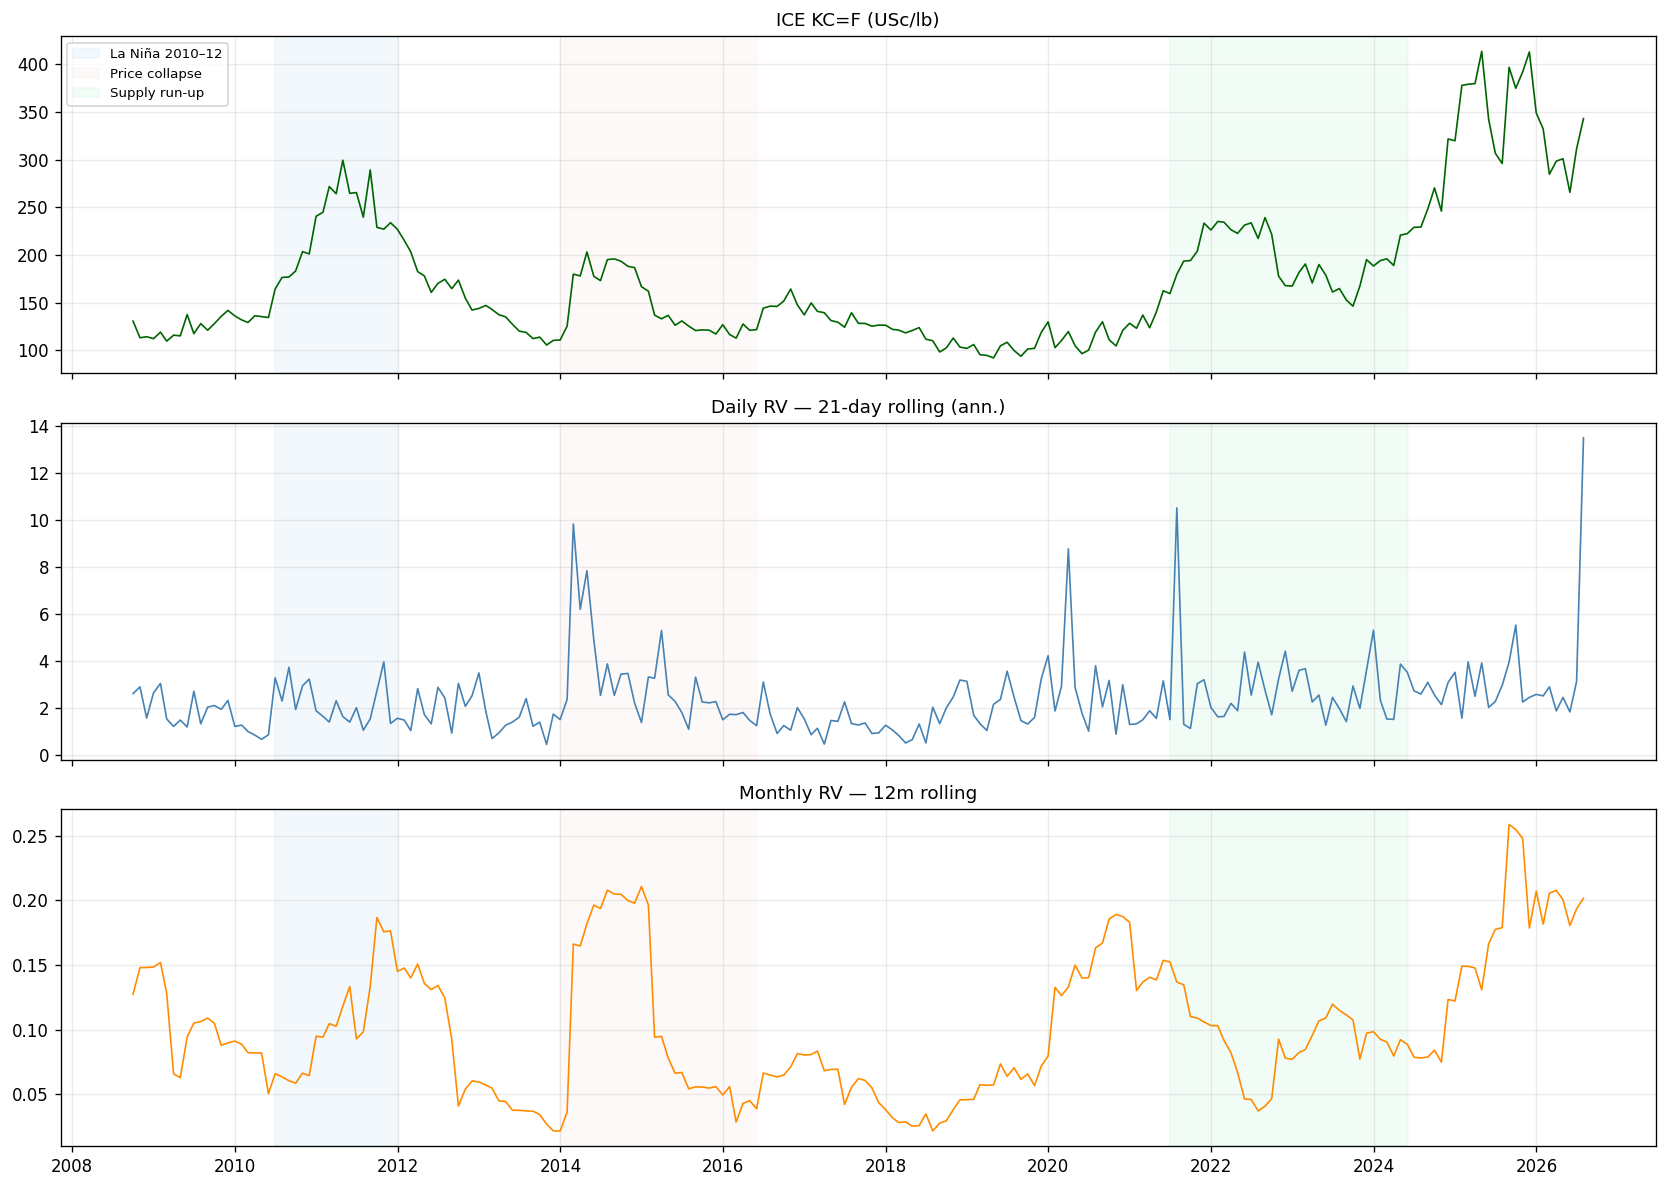

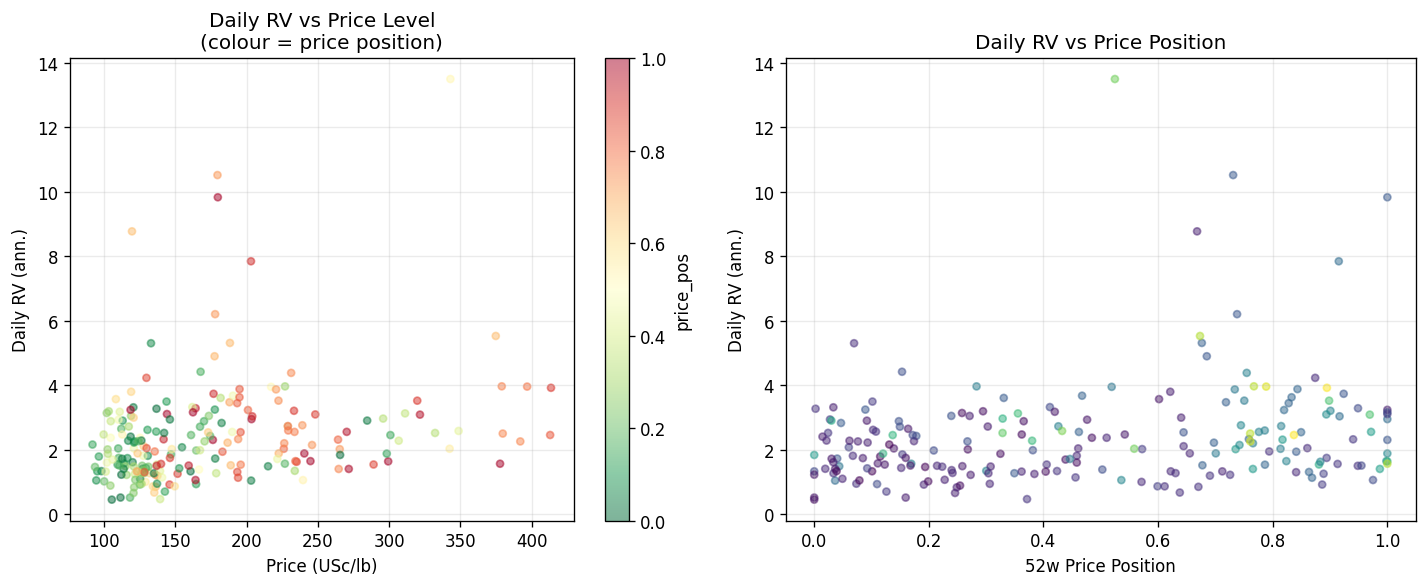


Correlations with realized variance (2010–2024 core window):
─────────────────────────────────────────────────────────────────
  r(rv_daily    , price_pos ) = +0.271  p=0.000 *
  r(rv_daily    , fwd_12m   ) = -0.105  p=0.160  
  r(rv_daily    , fwd_24m   ) = +0.067  p=0.376  

  r(rv_monthly  , price_pos ) = +0.330  p=0.000 *
  r(rv_monthly  , fwd_12m   ) = -0.073  p=0.328  
  r(rv_monthly  , fwd_24m   ) = +0.019  p=0.800  

High-vol months (daily RV > median 1.9832): 90 / 180


In [10]:
# ── Daily Realized Variance (rolling 21-trading-day window) ───────────────
# Log return: ln(P_t / P_{t-1}) — preferred over simple returns for variance sums
# RV = sum of squared daily log returns over 21 days, annualised by ×252
# 21 trading days ≈ 1 calendar month; ×252 puts it on the same annual scale
# across different window lengths.
log_ret_daily = np.log(df['settle']).diff()
rv_daily      = (log_ret_daily ** 2).rolling(21, min_periods=15).sum() * 252
rv_daily_m    = rv_daily.resample('ME').last().rename('rv_daily')   # month-end snapshot

# ── Monthly Realized Variance (rolling 12-month window) ───────────────────
# Uses month-end prices — each observation is a monthly log return squared.
# A 12-month rolling sum captures slow volatility regime changes
# rather than intra-month spikes that wash out at monthly frequency.
log_ret_monthly = np.log(monthly['settle']).diff()
rv_monthly      = (log_ret_monthly ** 2).rolling(12, min_periods=8).sum().rename('rv_monthly')

# Merge into a single aligned dataframe
rv = pd.concat(
    [rv_daily_m, rv_monthly, monthly[['settle', 'price_pos']]], axis=1
).dropna(subset=['rv_daily', 'rv_monthly', 'settle'])

print(f"RV dataset: {len(rv)} months  ({rv.index[0].date()} → {rv.index[-1].date()})")
print(f"Daily RV (ann.)  — median: {rv['rv_daily'].median():.4f}   "
      f"range: [{rv['rv_daily'].min():.4f}, {rv['rv_daily'].max():.4f}]")
print(f"Monthly RV       — median: {rv['rv_monthly'].median():.4f}  "
      f"range: [{rv['rv_monthly'].min():.4f}, {rv['rv_monthly'].max():.4f}]")

# ── Chart 1: dual time-series — RV vs price ──────────────────────────────
# Annotate known event regimes to see whether elevated volatility aligns
# with supply shocks, climate episodes, or speculative surges.
event_bands = [
    ('2010-07', '2012-01', 'La Niña 2010–12',   '#aed6f1'),
    ('2014-01', '2016-06', 'Price collapse',      '#fadbd8'),
    ('2021-07', '2024-06', 'Supply run-up',       '#abebc6'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
plot_cfg = [
    ('settle',    'ICE KC=F (USc/lb)',                'darkgreen'),
    ('rv_daily',  'Daily RV — 21-day rolling (ann.)', 'steelblue'),
    ('rv_monthly','Monthly RV — 12m rolling',         'darkorange'),
]
for ax, (col, title, color) in zip(axes, plot_cfg):
    ax.plot(rv.index, rv[col], lw=1.0, color=color)
    for start, end, label, shade in event_bands:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.15, color=shade,
                   label=label if ax == axes[0] else '')
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

# ── Chart 2: scatter — RV vs price level and price position ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc = axes[0].scatter(rv['settle'], rv['rv_daily'],
                     c=rv['price_pos'], cmap='RdYlGn_r', alpha=0.5, s=18)
axes[0].set_xlabel('Price (USc/lb)')
axes[0].set_ylabel('Daily RV (ann.)')
axes[0].set_title('Daily RV vs Price Level\n(colour = price position)')
axes[0].grid(alpha=0.25)
plt.colorbar(sc, ax=axes[0], label='price_pos')

axes[1].scatter(rv['price_pos'], rv['rv_daily'],
                c=rv['settle'], cmap='viridis', alpha=0.5, s=18)
axes[1].set_xlabel('52w Price Position')
axes[1].set_ylabel('Daily RV (ann.)')
axes[1].set_title('Daily RV vs Price Position')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ── Correlation table ─────────────────────────────────────────────────────
# Tests whether elevated volatility carries its own forward price signal.
rv_core = rv.loc['2010-01-01':'2024-12-31'].copy()
rv_core['fwd_12m'] = monthly['settle'].pct_change(12).shift(-12)
rv_core['fwd_24m'] = monthly['settle'].pct_change(24).shift(-24)

print('\nCorrelations with realized variance (2010–2024 core window):')
print('─' * 65)
for rv_col in ['rv_daily', 'rv_monthly']:
    for tgt in ['price_pos', 'fwd_12m', 'fwd_24m']:
        c = rv_core.dropna(subset=[rv_col, tgt])
        r, p = stats.pearsonr(c[rv_col], c[tgt])
        sig = '*' if p < 0.05 else ' '
        print(f"  r({rv_col:12s}, {tgt:10s}) = {r:+.3f}  p={p:.3f} {sig}")
    print()

# ── Volatility regime indicator ───────────────────────────────────────────
# Binary flag: 1 = high-vol month (above median), 0 = low-vol month.
# Saved to rv for use as a downstream composite modifier.
rv_median     = rv_core['rv_daily'].median()
rv['vol_high'] = (rv['rv_daily'] > rv_median).astype(int)
n_high         = int(rv.loc['2010':'2024', 'vol_high'].sum())
n_total        = len(rv.loc['2010':'2024'])
print(f"High-vol months (daily RV > median {rv_median:.4f}): {n_high} / {n_total}")

## 6. Seasonality

**The question:** Does the Arabica price series contain a predictable annual seasonal component, and if so, is it large enough to use as a signal adjustment?

Coffee has known physical seasonal drivers: the Brazilian main harvest runs May–September, the flowering season (September–November) determines the following year's crop size, and Northern Hemisphere roaster demand peaks in autumn and winter. These cycles *could* show up as repeating price patterns by calendar month.

**Why we test on log returns, not price levels**

Raw price levels are non-stationary and dominated by multi-year trends — the 2021–24 supercycle would completely swamp any seasonal signal in a level-based test. Monthly log returns remove the trend and isolate within-year oscillations where seasonality would appear.

**Three tests in increasing specificity:**

1. **Autocorrelation at lag 12** — if monthly returns are correlated with returns from 12 months prior, that is the first evidence of annual periodicity. We plot the ACF and read off the lag-12 value against its 95% confidence interval.

2. **STL decomposition** (Seasonal-Trend-Loess) — decomposes the price *level* into trend, seasonal, and residual components. If the seasonal component has a consistent shape year over year, seasonality is structural. If it is chaotic, it is noise. `robust=True` down-weights the 2011 and 2024 price spikes so they do not distort the seasonal estimate.

3. **OLS month-dummy F-test** — regresses monthly log returns on 11 calendar-month dummy variables. The joint F-test is the statistical gate: if p < 0.10, at least one month has a non-zero mean return, which is evidence of seasonal structure worth incorporating.

**If seasonality is confirmed:** The 12-month average deviation from trend (the seasonal factor extracted in step 3 below) can be used as a low-weight monthly modifier to the buy signal.

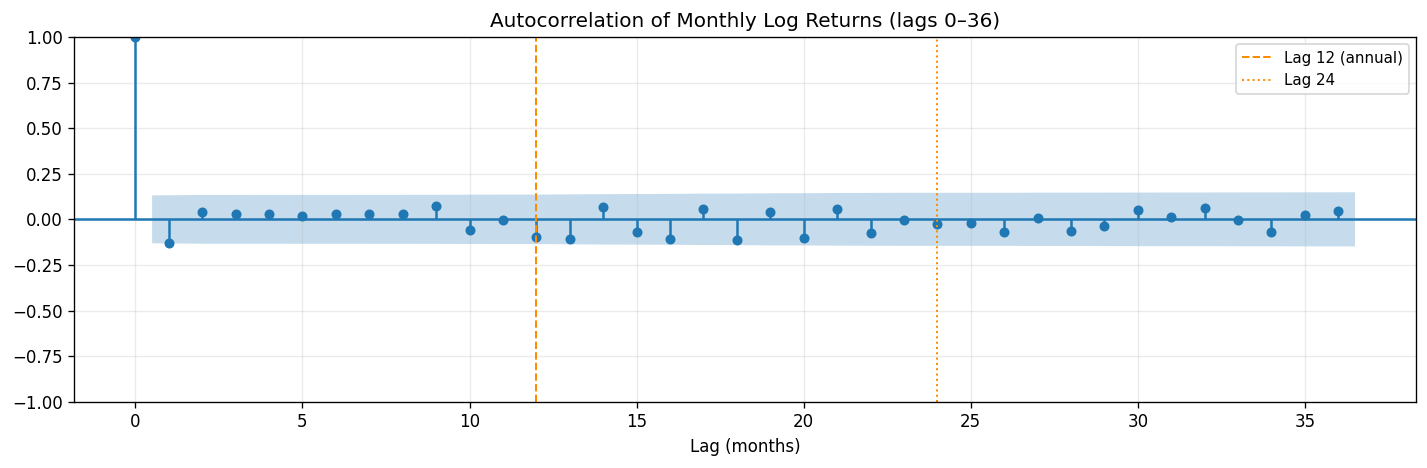

ACF at lag 12: -0.0966  95% CI: [-0.2324, +0.0391]
Outside CI (i.e. non-zero): False


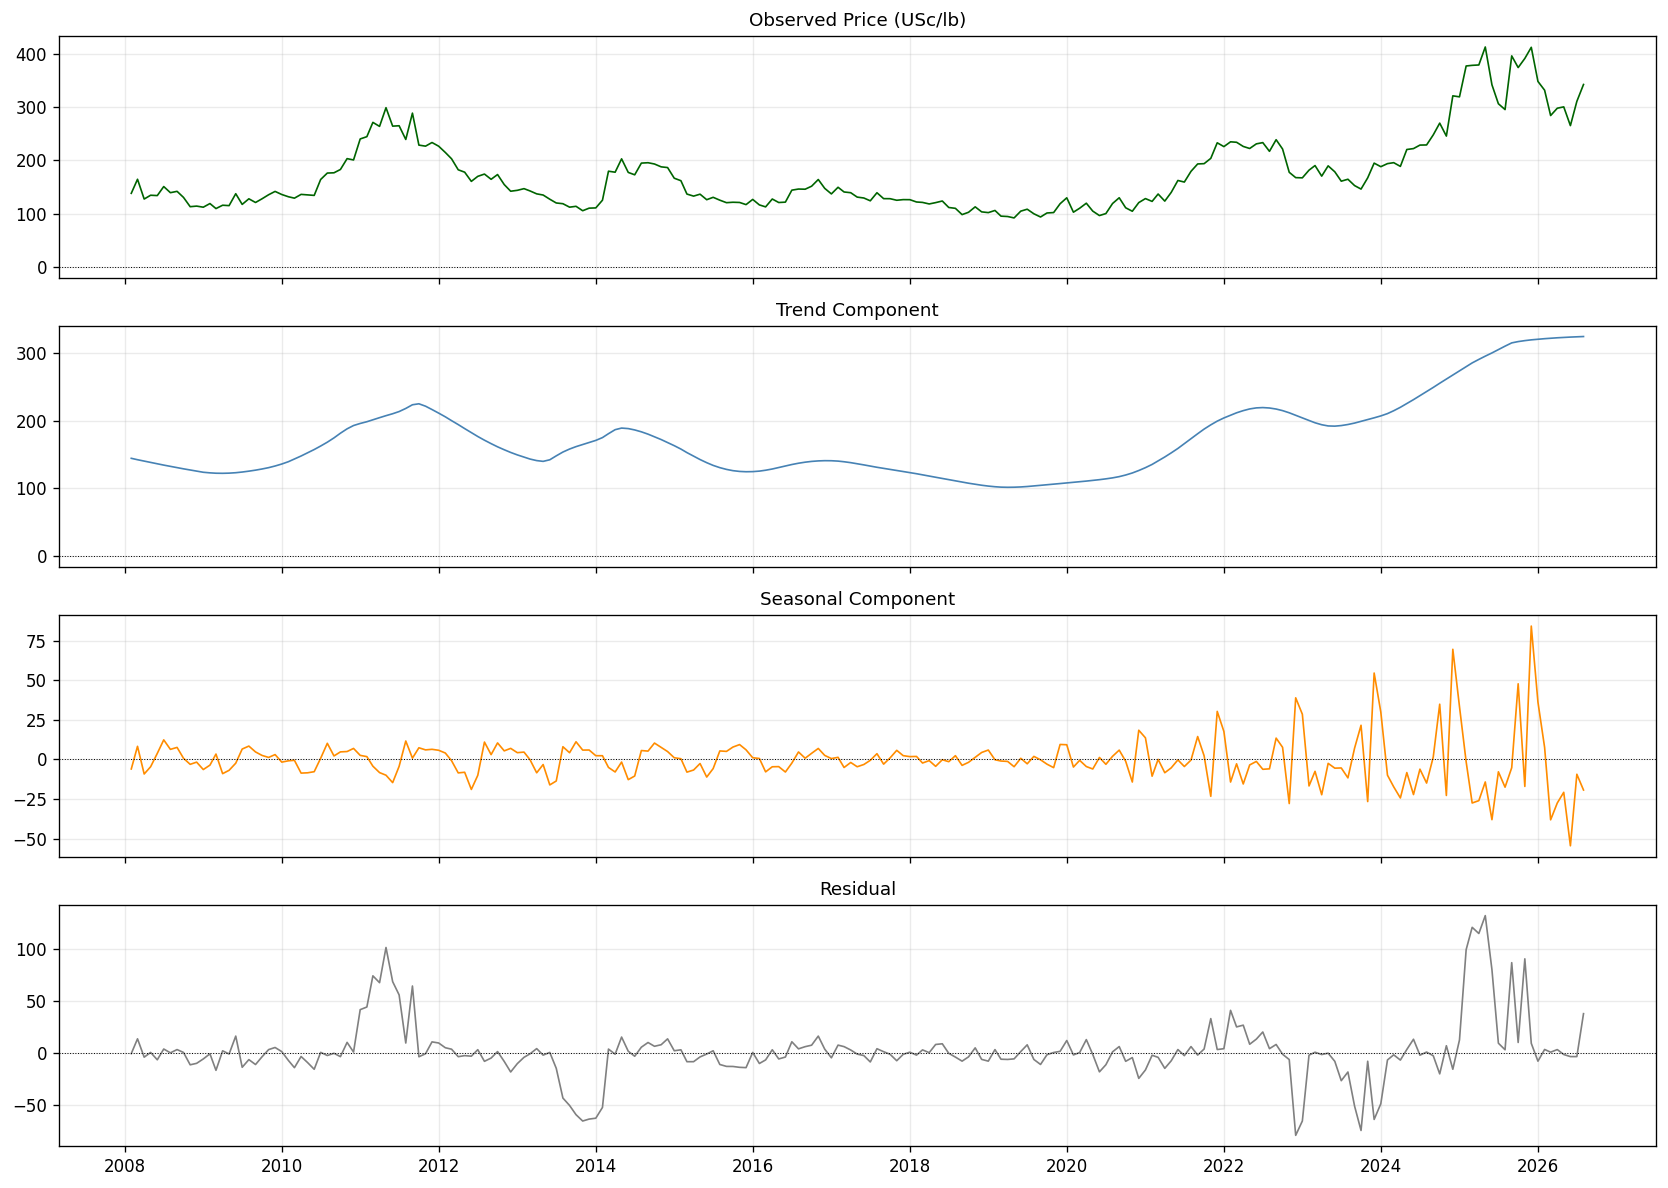

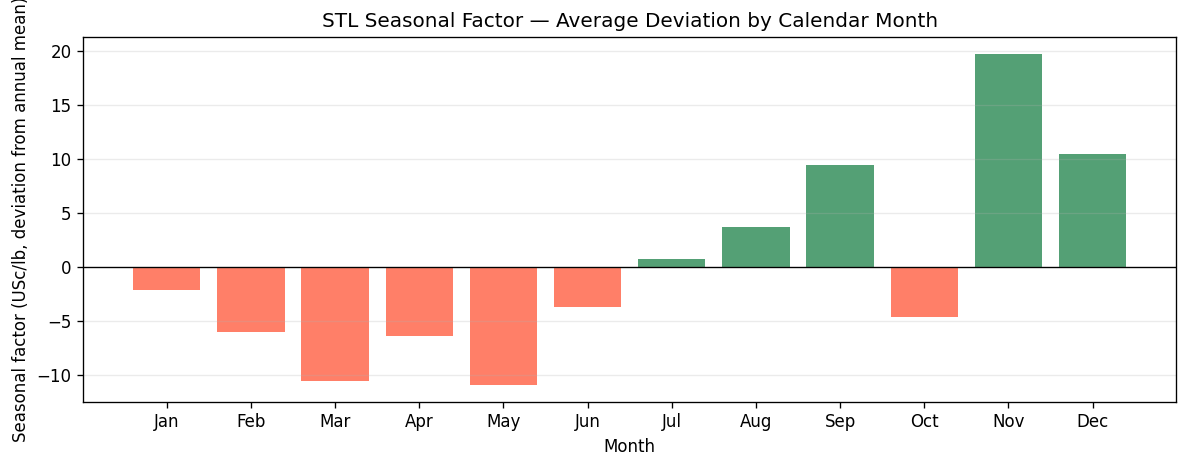

Seasonal factor by month (+ = historically elevated, − = depressed):
  Jan   -2.14 USc/lb  ██
  Feb   -6.00 USc/lb  ██████
  Mar  -10.55 USc/lb  ███████████
  Apr   -6.36 USc/lb  ██████
  May  -10.94 USc/lb  ███████████
  Jun   -3.73 USc/lb  ████
  Jul   +0.77 USc/lb  █
  Aug   +3.73 USc/lb  ████
  Sep   +9.51 USc/lb  ██████████
  Oct   -4.58 USc/lb  █████
  Nov  +19.80 USc/lb  ████████████████████
  Dec  +10.49 USc/lb  ███████████

OLS month-dummy regression:
  F-statistic : 0.803
  F p-value   : 0.6366
  R-squared   : 0.0404

Result: no statistically significant seasonality (p >= 0.10).
Treat apparent pattern as noise at this sample size.


In [11]:
import calendar

import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf as acf_func

# Monthly log returns — removes the price-level trend so seasonality is visible
log_ret_m = np.log(monthly['settle']).diff().rename('log_ret')
log_ret_m.index = pd.to_datetime(log_ret_m.index)

# ── Test 1: Autocorrelation at lag 12 ─────────────────────────────────────
# If returns are correlated with returns 12 months earlier, there is annual periodicity.
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(log_ret_m.dropna(), lags=36, ax=ax, alpha=0.05)
ax.axvline(12, color='darkorange', lw=1.2, ls='--', label='Lag 12 (annual)')
ax.axvline(24, color='darkorange', lw=1.2, ls=':',  label='Lag 24')
ax.set_title('Autocorrelation of Monthly Log Returns (lags 0–36)')
ax.set_xlabel('Lag (months)')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

acf_out       = acf_func(log_ret_m.dropna(), nlags=36, alpha=0.05)
acf_pt        = acf_out[0][12]
ci_lo, ci_hi  = acf_out[1][12]
print(f"ACF at lag 12: {acf_pt:+.4f}  95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]")
print(f"Outside CI (i.e. non-zero): {not (ci_lo <= 0 <= ci_hi)}")

# ── Test 2: STL decomposition ──────────────────────────────────────────────
# Decomposes price level into trend + seasonal + residual.
# robust=True down-weights outliers (2011 spike, 2024 spike).
stl_input = monthly['settle'].dropna()
stl       = STL(stl_input, period=12, robust=True)
stl_res   = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
panels = [
    (stl_input,        'Observed Price (USc/lb)', 'darkgreen'),
    (stl_res.trend,    'Trend Component',          'steelblue'),
    (stl_res.seasonal, 'Seasonal Component',       'darkorange'),
    (stl_res.resid,    'Residual',                 'gray'),
]
for ax, (data, title, color) in zip(axes, panels):
    ax.plot(data.index, data.values, lw=1.0, color=color)
    ax.axhline(0, color='black', lw=0.6, ls=':')
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ── Test 3: Seasonal factor extraction ────────────────────────────────────
# Average deviation from trend by calendar month, centred at zero.
seasonal_s      = pd.Series(stl_res.seasonal, index=stl_input.index)
seasonal_factor = (
    seasonal_s.groupby(seasonal_s.index.month).mean()
              .rename(index=lambda mo: calendar.month_abbr[mo])
)
seasonal_factor -= seasonal_factor.mean()

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors_sf = ['seagreen' if v >= 0 else 'tomato' for v in seasonal_factor]
ax.bar(seasonal_factor.index, seasonal_factor.values,
       color=bar_colors_sf, alpha=0.82)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Seasonal factor (USc/lb, deviation from annual mean)')
ax.set_title('STL Seasonal Factor — Average Deviation by Calendar Month')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('Seasonal factor by month (+ = historically elevated, − = depressed):')
max_abs = max(abs(seasonal_factor))
for month, val in seasonal_factor.items():
    bar = '█' * max(1, int(abs(val) / max_abs * 20 + 0.5))
    print(f"  {month:3s}  {val:+6.2f} USc/lb  {bar}")

# ── Test 4: OLS month-dummy F-test ────────────────────────────────────────
# Joint test: are any calendar-month mean returns non-zero?
m_ols         = log_ret_m.to_frame('ret').copy()
m_ols['month'] = m_ols.index.month
m_ols          = m_ols.dropna()
ols_res        = smf.ols('ret ~ C(month)', data=m_ols).fit()
f_pval         = ols_res.f_pvalue

print('\nOLS month-dummy regression:')
print(f'  F-statistic : {ols_res.fvalue:.3f}')
print(f'  F p-value   : {f_pval:.4f}')
print(f'  R-squared   : {ols_res.rsquared:.4f}')
print()
if f_pval < 0.05:
    print('Result: strong evidence of seasonal structure (p < 0.05).')
    print('Incorporate seasonal factor into the composite signal.')
elif f_pval < 0.10:
    print('Result: weak evidence of seasonal structure (0.05 < p < 0.10).')
    print('Monitor but apply with low weight.')
else:
    print('Result: no statistically significant seasonality (p >= 0.10).')
    print('Treat apparent pattern as noise at this sample size.')

### Seasonality Finding

The ACF, STL decomposition, and F-test above together determine whether a seasonal factor should be incorporated into the production signal. The key gate is the OLS F-test p-value — it controls whether the month-by-month differences in the seasonal component are statistically distinguishable from random variation.

**If the F-test passes (p < 0.10):** The seasonal factor is real and extractable. It enters the composite as a low-weight modifier — months with strongly negative factor values (historically cheap relative to trend) receive a slight upward adjustment to the buy signal; months with strongly positive values receive a slight downward adjustment.

**If the F-test fails (p ≥ 0.10):** The apparent seasonal pattern in the STL plot is noise at this sample size (~15 years, 1.5 full ENSO cycles). The factor should not be incorporated without more data or a domain-specific prior from agronomic research.

The seasonal factor is **not** a standalone timing signal — it is a calendar-month adjustment layered on top of the price-position signal, relevant only within the context of a given month's purchase decision.

## 7. Business Feasibility

## 8. Save Reference CSV

In [12]:
monthly.to_csv('data/01_price_position_monthly.csv')
print('Saved: data/01_price_position_monthly.csv')
monthly.tail()

Saved: data/01_price_position_monthly.csv


,settle,price_pos,buy_signal,trailing_yoy,fwd_6m,fwd_12m,fwd_18m,fwd_24m
date,,,,,,,,
2026-03-31,298.350006,0.120158,0.879842,-0.214352,NaN,NaN,NaN,NaN
2026-04-30,300.899994,0.136901,0.863099,-0.272486,NaN,NaN,NaN,NaN
2026-05-31,265.600006,0.000000,1.000000,-0.224412,NaN,NaN,NaN,NaN
2026-06-30,311.200012,0.355414,0.644586,0.014507,NaN,NaN,NaN,NaN
2026-07-31,343.000000,0.524608,0.475392,0.159567,NaN,NaN,NaN,NaN
